## Pokémon Victory Prediction Challenge: Data Preparation

In [12]:
import pandas as pd
import zipfile
import os

# Path to the zip file
zip_file_path = '/content/Pokemon Data Analysis Tutorial.zip'

# Directory to extract the contents to
extract_dir = '/content/pokemon_data/'

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted data to: {extract_dir}")

# List contents of the extracted directory to find the actual CSV files
print("Contents of extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))

# Assuming the files are now in a subfolder like 'Pokemon Data Analysis Tutorial' within extract_dir
# Let's find the actual base path for the CSV files
actual_data_path = extract_dir
for root, dirs, files in os.walk(extract_dir):
    if 'pokemon.csv' in files and 'combats.csv' in files:
        actual_data_path = root
        break

print(f"\nActual data path found: {actual_data_path}")

# Load pokemon.csv from the corrected directory
pokemon_df = pd.read_csv(os.path.join(actual_data_path, 'pokemon.csv'))
print("pokemon.csv loaded successfully. Head of the DataFrame:")
display(pokemon_df.head())

# Load combats.csv from the corrected directory
combats_df = pd.read_csv(os.path.join(actual_data_path, 'combats.csv'))
print("\ncombats.csv loaded successfully. Head of the DataFrame:")
display(combats_df.head())


Extracted data to: /content/pokemon_data/
Contents of extracted directory:
/content/pokemon_data/Pokemon Data Analysis Tutorial/pokemon.csv
/content/pokemon_data/Pokemon Data Analysis Tutorial/combats.csv
/content/pokemon_data/Pokemon Data Analysis Tutorial/tests.csv

Actual data path found: /content/pokemon_data/Pokemon Data Analysis Tutorial
pokemon.csv loaded successfully. Head of the DataFrame:


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False



combats.csv loaded successfully. Head of the DataFrame:


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


## Data Preparation: Merging DataFrames

In [13]:
# Rename the '#' column in pokemon_df to 'Pokemon_ID' for easier merging
pokemon_df = pokemon_df.rename(columns={'#': 'Pokemon_ID'})

# Display info for pokemon_df to check for 'Name' column and 'Type 2'
print("\nInfo for pokemon_df before handling missing values:")
display(pokemon_df.info())

# Fill missing 'Name' for Pokémon #62 (Primeape)
# First, identify if Pokemon_ID 62 has a missing name
if pokemon_df[pokemon_df['Pokemon_ID'] == 62]['Name'].isnull().any():
    pokemon_df.loc[pokemon_df['Pokemon_ID'] == 62, 'Name'] = 'Primeape'
    print("Filled missing 'Name' for Pokemon_ID 62 with 'Primeape'.")

# Fill missing 'Type 2' with 'None'
pokemon_df['Type 2'] = pokemon_df['Type 2'].fillna('None')
print("Filled missing 'Type 2' values with 'None'.")

print("\nPokemon DataFrame after handling missing values:")
display(pokemon_df.head())
display(pokemon_df[pokemon_df['Pokemon_ID'] == 62]) # Verify Primeape's name
display(pokemon_df.isnull().sum()) # Verify no more missing values for 'Name' and 'Type 2'



Info for pokemon_df before handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Pokemon_ID  800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


None

Filled missing 'Type 2' values with 'None'.

Pokemon DataFrame after handling missing values:


,Pokemon_ID,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False


,Pokemon_ID,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
61,62,Mankey,Fighting,None,40,80,35,35,45,70,1,False


,0
Pokemon_ID,0
Name,1
Type 1,0
Type 2,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


Now that the missing values in `pokemon_df` are handled, we can proceed to calculate the win percentage for each Pokémon. This involves iterating through the `combats_df` to count wins and total battles for each Pokémon.

In [14]:
# Calculate win percentage for each Pokémon

# Initialize dictionaries to store total battles and wins for each Pokémon
total_battles = {}
wins = {}

# Iterate through each combat record
for index, row in combats_df.iterrows():
    first_pokemon = row['First_pokemon']
    second_pokemon = row['Second_pokemon']
    winner = row['Winner']

    # Update total battles for both Pokémon
    total_battles[first_pokemon] = total_battles.get(first_pokemon, 0) + 1
    total_battles[second_pokemon] = total_battles.get(second_pokemon, 0) + 1

    # Update wins for the winner
    wins[winner] = wins.get(winner, 0) + 1

# Create a DataFrame for win/loss records
win_loss_df = pd.DataFrame({
    'Pokemon_ID': list(total_battles.keys()),
    'Total_Battles': list(total_battles.values()),
    'Wins': [wins.get(pid, 0) for pid in total_battles.keys()]
})

# Calculate win percentage
win_loss_df['Win_Percentage'] = (win_loss_df['Wins'] / win_loss_df['Total_Battles']) * 100

# Merge win_loss_df with pokemon_df
pokemon_df_merged = pd.merge(pokemon_df, win_loss_df, on='Pokemon_ID', how='left')

# For Pokémon that did not participate in any battles, their 'Total_Battles', 'Wins', and 'Win_Percentage' will be NaN.
# Fill these with 0.
pokemon_df_merged[['Total_Battles', 'Wins', 'Win_Percentage']] = pokemon_df_merged[['Total_Battles', 'Wins', 'Win_Percentage']].fillna(0)

print("\nMerged DataFrame with Win Percentage:")
display(pokemon_df_merged.head())
display(pokemon_df_merged.tail())
display(pokemon_df_merged.info())



Merged DataFrame with Win Percentage:


,Pokemon_ID,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Total_Battles,Wins,Win_Percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133.0,37.0,27.819549
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121.0,46.0,38.016529
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132.0,89.0,67.424242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125.0,70.0,56.000000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,112.0,55.0,49.107143


,Pokemon_ID,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Total_Battles,Wins,Win_Percentage
795,796,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True,105.0,39.0,37.142857
796,797,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True,131.0,116.0,88.549618
797,798,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True,119.0,60.0,50.420168
798,799,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True,144.0,89.0,61.805556
799,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True,121.0,75.0,61.983471


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pokemon_ID      800 non-null    int64  
 1   Name            799 non-null    object 
 2   Type 1          800 non-null    object 
 3   Type 2          800 non-null    object 
 4   HP              800 non-null    int64  
 5   Attack          800 non-null    int64  
 6   Defense         800 non-null    int64  
 7   Sp. Atk         800 non-null    int64  
 8   Sp. Def         800 non-null    int64  
 9   Speed           800 non-null    int64  
 10  Generation      800 non-null    int64  
 11  Legendary       800 non-null    bool   
 12  Total_Battles   800 non-null    float64
 13  Wins            800 non-null    float64
 14  Win_Percentage  800 non-null    float64
dtypes: bool(1), float64(3), int64(8), object(3)
memory usage: 88.4+ KB


None

## Exploratory Data Analysis (EDA) and Visualization: Correlation Analysis


Correlation Matrix:


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Win_Percentage
HP,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.234889
Attack,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.476675
Defense,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.113312
Sp. Atk,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.455848
Sp. Def,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.291603
Speed,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,0.905409
Win_Percentage,0.234889,0.476675,0.113312,0.455848,0.291603,0.905409,1.000000


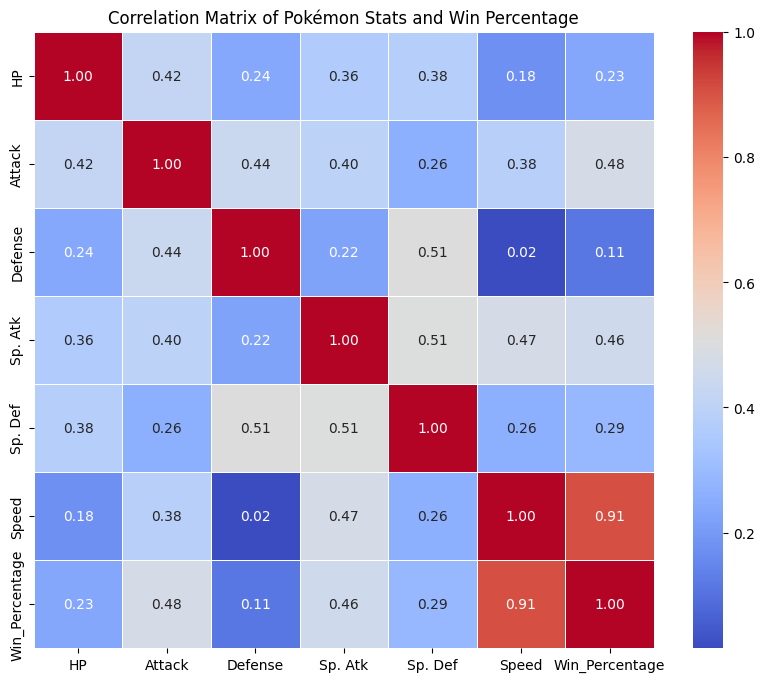

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select relevant columns for correlation analysis
correlation_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']
correlation_df = pokemon_df_merged[correlation_cols]

# Calculate the correlation matrix
corr_matrix = correlation_df.corr()

print("\nCorrelation Matrix:")
display(corr_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Pokémon Stats and Win Percentage')
plt.show()


The heatmap gives us a good overview of the linear relationships. Now, let's create a Seaborn `pairplot` or `PairGrid` to visualize the distributions and pairwise relationships between these selected stats and the win percentage. This will provide more detailed insights into how these features interact.

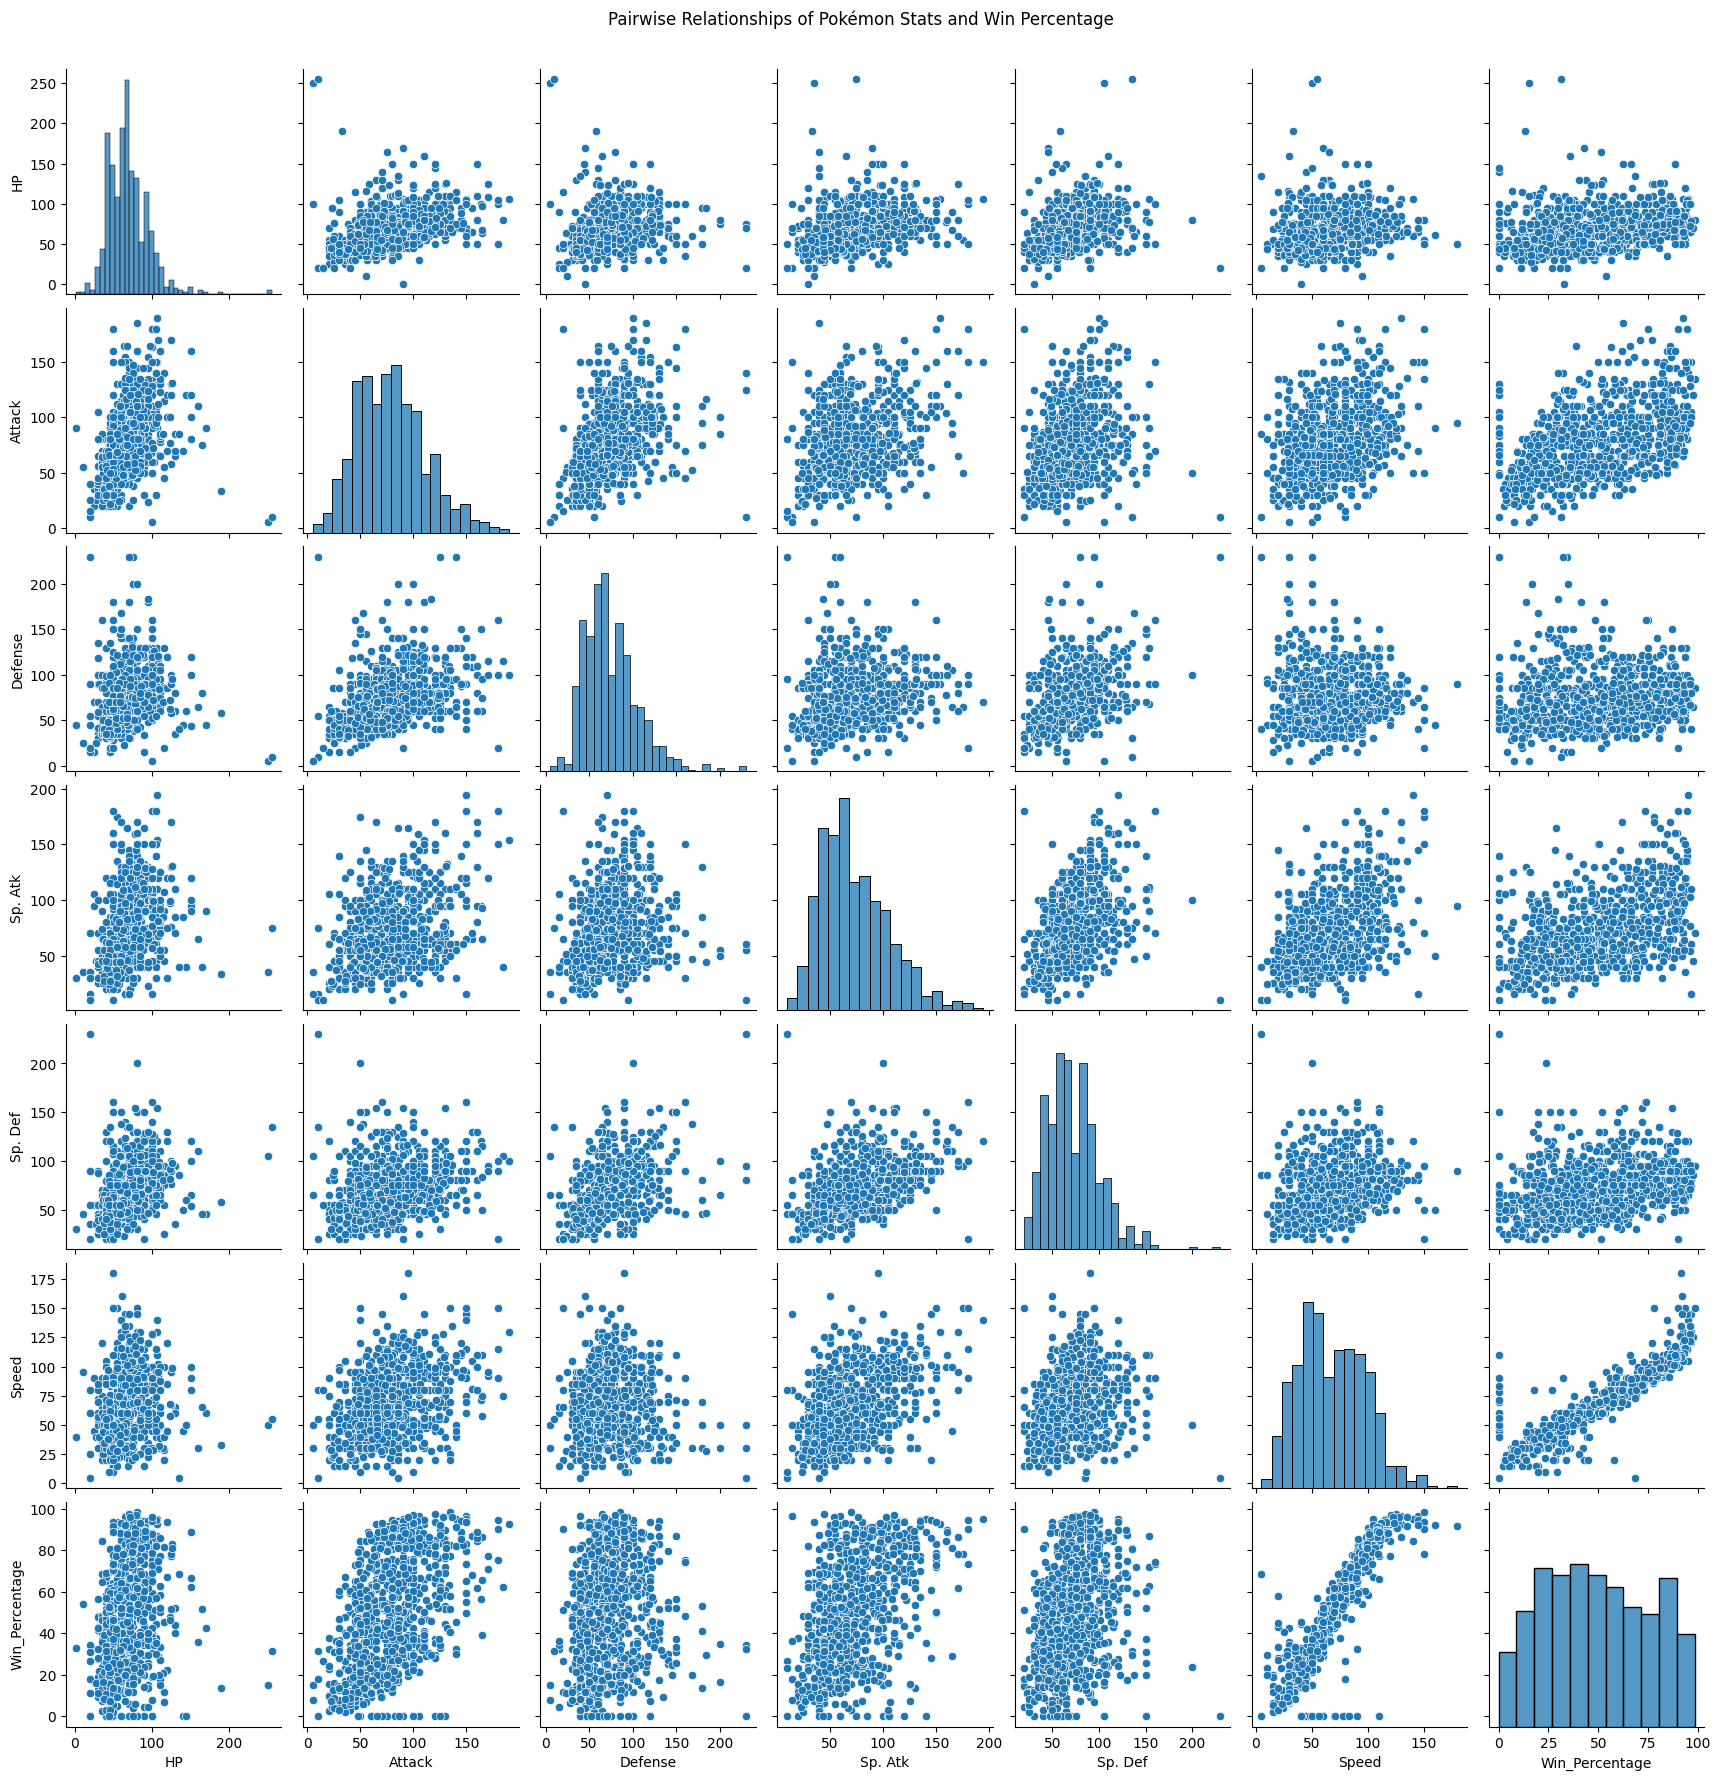

In [16]:
# Create a pairplot to visualize relationships between stats and Win_Percentage
sns.pairplot(correlation_df)
plt.suptitle('Pairwise Relationships of Pokémon Stats and Win Percentage', y=1.02) # Adjust suptitle position
plt.show()


Finally, let's identify and display the top 10 Pokémon based on their win percentage, along with their key statistics. This will help us see if there's a clear pattern in the stats of high-performing Pokémon.

In [17]:
# Analyze the top 10 Pokémon by Win Percentage
top_10_pokemon = pokemon_df_merged.sort_values(by='Win_Percentage', ascending=False).head(10)

print("\nTop 10 Pokémon by Win Percentage and their Stats:")
display(top_10_pokemon[['Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']])



Top 10 Pokémon by Win Percentage and their Stats:


,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Win_Percentage
154,Mega Aerodactyl,Rock,Flying,80,135,85,70,95,150,98.449612
512,Weavile,Dark,Ice,70,120,65,45,85,125,97.478992
703,Tornadus Therian Forme,Flying,None,79,100,80,110,90,121,96.800000
19,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,96.638655
153,Aerodactyl,Rock,Flying,80,105,65,60,75,130,96.453901
476,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,96.124031
726,Greninja,Water,Dark,72,95,67,103,71,122,96.062992
716,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,77,77,128,95.934959
164,Mega Mewtwo Y,Psychic,None,106,150,70,194,120,140,95.200000
349,Mega Sharpedo,Water,Dark,70,140,70,110,65,105,95.000000


## Machine Learning: Model Training and Evaluation

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Define features (X) and target (y)
# Drop non-numeric columns and identifier columns that are not features for prediction
X = pokemon_df_merged.drop(columns=['Pokemon_ID', 'Name', 'Type 1', 'Type 2', 'Total_Battles', 'Wins', 'Win_Percentage'])
y = pokemon_df_merged['Win_Percentage']

# Convert boolean 'Legendary' column to int (0 or 1)
X['Legendary'] = X['Legendary'].astype(int)

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nData split successfully. Ready to train models.")


Shape of X_train: (640, 8)
Shape of X_test: (160, 8)
Shape of y_train: (640,)
Shape of y_test: (160,)

Data split successfully. Ready to train models.


Now, let's train and evaluate three different regression models: Linear Regression, Random Forest Regressor, and XGBoost Regressor. We will compare their performance using Mean Absolute Error (MAE).

In [19]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'XGBoost Regressor': XGBRegressor(random_state=42)
}

# Dictionary to store MAE for each model
mae_scores = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores[name] = mae
    print(f"{name} MAE: {mae:.4f}")

# Compare model performance
print("\n--- Model Performance Comparison (Mean Absolute Error) ---")
for name, mae in mae_scores.items():
    print(f"{name}: {mae:.4f}")

best_model = min(mae_scores, key=mae_scores.get)
print(f"\nThe best performing model is {best_model} with an MAE of {mae_scores[best_model]:.4f}")



Training Linear Regression...
Linear Regression MAE: 6.3687

Training Random Forest Regressor...
Random Forest Regressor MAE: 5.7642

Training XGBoost Regressor...
XGBoost Regressor MAE: 6.2760

--- Model Performance Comparison (Mean Absolute Error) ---
Linear Regression: 6.3687
Random Forest Regressor: 5.7642
XGBoost Regressor: 6.2760

The best performing model is Random Forest Regressor with an MAE of 5.7642
